In [1]:
"""
Example script to run the electricity model.
It consists of three parts:
1. Generation
2. Grid
3. Storage
"""

import pandas as pd
import numpy as np
import xarray as xr
import scipy
import warnings
from pathlib import Path
import warnings
from pint.errors import UnitStrippedWarning
warnings.simplefilter("ignore", UnitStrippedWarning)


from imagematerials.electricity.preprocessing import (
    get_preprocessing_data_gen,
    get_preprocessing_data_grid,
    get_preprocessing_data_stor
)
# from imagematerials.util import import_from_netcdf, export_to_netcdf
from imagematerials.model import GenericMainModel, GenericMaterials, GenericStocks, Maintenance, MaterialIntensities, SharesInflowStocks
from imagematerials.factory import ModelFactory, Sector
import prism

VARIANT = "VLHO"
SCEN = "SSP2"
scen_folder = SCEN + "_" + VARIANT
# path_base = Path().resolve() # TODO absolute path of file "preprocessing.py" ? current solution can differ depending on IDE used (?) 
path_current = Path().resolve()
path_base = path_current.parent #.parent # base path of the project -> image-materials

# create the folder out_test if it does not exist
if not (path_base / 'imagematerials' / 'electricity' / 'out_test').is_dir():
    (path_base / 'imagematerials' / 'electricity' / 'out_test').mkdir(parents=True)

YEAR_START = 1971   # start year of the simulation period
YEAR_END = 2100     # end year of the calculations
YEAR_OUT = 2100     # year of output generation = last year of reporting

# Combined -------------------------------------------------------------

In [8]:
# generation
prep_data = get_preprocessing_data_gen(path_base, SCEN, VARIANT, YEAR_START, YEAR_END, YEAR_OUT)
sec_electr_gen = Sector("electr_gen", prep_data)
# grid
prep_data_lines, prep_data_add = get_preprocessing_data_grid(path_base, SCEN, VARIANT, YEAR_START, YEAR_END, YEAR_OUT)
sec_electr_grid_lines = Sector("electr_grid_lines", prep_data_lines)
sec_electr_grid_add = Sector("electr_grid_add", prep_data_add)
# storage
prep_data_phs, prep_data_oth_storage = get_preprocessing_data_stor(path_base, SCEN, VARIANT, YEAR_START, YEAR_END, YEAR_OUT)
sec_electr_stor_phs = Sector("electr_stor_phs", prep_data_phs)
sec_electr_stor_oth = Sector("electr_stor_oth", prep_data_oth_storage, check_coordinates=False)

time_start = prep_data["stocks"].coords["Time"].min().values
complete_timeline = prism.Timeline(time_start, YEAR_END, 1)
simulation_timeline = prism.Timeline(YEAR_START, YEAR_END, 1)


factory = ModelFactory(
    [sec_electr_gen, 
    sec_electr_grid_lines, 
    sec_electr_grid_add,
    sec_electr_stor_phs,
    sec_electr_stor_oth], complete_timeline
    ).add(GenericStocks, ["electr_gen", 
                            "electr_grid_lines",
                            "electr_grid_add",
                            "electr_stor_phs"
                            ] 
    ).add(SharesInflowStocks, "electr_stor_oth"
    ).add(MaterialIntensities, ["electr_gen", 
                            "electr_grid_lines",
                            "electr_grid_add",
                            "electr_stor_phs",
                            "electr_stor_oth"
                            ]
    ).finish()

factory.simulate(simulation_timeline)

list(factory.electr_gen)

Path to image output: C:\Users\Judit\PhD\Coding\image-materials\data\raw\image\SSP2_VLHO\EnergyServices
grid_stock_lines to xarray Dataset
materials_grid_kgperkm to xarray Dataset
lifetime_grid_distr not in conversion_table
grid_stock_add to xarray Dataset
materials_grid_add_kgperunit to xarray Dataset
lifetime_grid_distr not in conversion_table
Path to image output: C:\Users\Judit\PhD\Coding\image-materials\data\raw\image\SSP2_VLHO\EnergyServices
phs_stock to xarray Dataset
phs_materials to xarray Dataset
phs_lifetime_distr not in conversion_table
oth_storage_stock to xarray Dataset
oth_storage_lifetime_distr not in conversion_table
oth_storage_shares to xarray Dataset


['lifetimes',
 'stocks',
 'material_intensities',
 'knowledge_graph',
 'set_unit_flexible',
 'outflow_by_cohort',
 'inflow',
 'stock_by_cohort',
 'stock_by_cohort_materials',
 'inflow_materials',
 'outflow_by_cohort_materials']

In [9]:
factory.stocks.keys()
# factory.stocks["electr_stor_oth"]


dict_keys(['electr_gen', 'electr_grid_lines', 'electr_grid_add', 'electr_stor_phs', 'electr_stor_oth'])

# Generation -------------------------------------------------------

In [ ]:
print("Base path:", path_base)
prep_data = get_preprocessing_data_gen(path_base, SCEN, VARIANT, YEAR_START, YEAR_END, YEAR_OUT)

Base path: C:\Users\Judit\PhD\Coding\image-materials
Path to image output: C:\Users\Judit\PhD\Coding\image-materials\data\raw\image\SSP2_VLHO\EnergyServices
gcap_stock to xarray Dataset
gcap_types_materials to xarray Dataset
gcap_lifetime_distr not in conversion_table


In [4]:
# Define the complete timeline, including historic tail
time_start = prep_data["stocks"].coords["Time"].min().values
complete_timeline = prism.Timeline(time_start, YEAR_END, 1)
simulation_timeline = prism.Timeline(YEAR_START, YEAR_END, 1)

sec_electr_gen = Sector("electr_gen", prep_data)

main_model_factory = ModelFactory(
    sec_electr_gen, complete_timeline
    ).add(GenericStocks
    ).add(MaterialIntensities
    ).finish()

main_model_factory.simulate(simulation_timeline)

list(main_model_factory.electr_gen)

['gcap_lifetime_distr',
 'stocks',
 'material_intensities',
 'lifetimes',
 'knowledge_graph',
 'set_unit_flexible',
 'outflow_by_cohort',
 'inflow',
 'stock_by_cohort',
 'stock_by_cohort_materials',
 'inflow_materials',
 'outflow_by_cohort_materials']

# Grid -------------------------------------------------------------

In [ ]:
prep_data_lines, prep_data_add = get_preprocessing_data_grid(path_base, SCEN, VARIANT, YEAR_START, YEAR_END, YEAR_OUT)

grid_stock_lines to xarray Dataset
materials_grid_kgperkm to xarray Dataset
lifetime_grid_distr not in conversion_table
grid_stock_add to xarray Dataset
materials_grid_add_kgperunit to xarray Dataset
lifetime_grid_distr not in conversion_table


## Lines ----

In [ ]:
# Define the complete timeline, including historic tail
time_start = prep_data_lines["stocks"].coords["Time"].min().values
complete_timeline = prism.Timeline(time_start, YEAR_END, 1)
simulation_timeline = prism.Timeline(YEAR_START, YEAR_END, 1)

sec_electr_grid_lines = Sector("electr_grid_lines", prep_data_lines)

main_model_factory_lines = ModelFactory(
    sec_electr_grid_lines, complete_timeline
    ).add(GenericStocks
    ).add(MaterialIntensities
    ).finish()

main_model_factory_lines.simulate(simulation_timeline)
list(main_model_factory_lines.electr_grid_lines)

['lifetime_grid_distr',
 'stocks',
 'material_intensities',
 'lifetimes',
 'knowledge_graph',
 'set_unit_flexible',
 'outflow_by_cohort',
 'inflow',
 'stock_by_cohort',
 'stock_by_cohort_materials',
 'inflow_materials',
 'outflow_by_cohort_materials']

## Grid Additions ----

In [ ]:
time_start = prep_data_add["stocks"].coords["Time"].min().values
complete_timeline = prism.Timeline(time_start, YEAR_END, 1)
simulation_timeline = prism.Timeline(YEAR_START, YEAR_END, 1)

sec_electr_grid_add = Sector("electr_grid_add", prep_data_add)

main_model_factory_add = ModelFactory(
    sec_electr_grid_add, complete_timeline
    ).add(GenericStocks
    ).add(MaterialIntensities
    ).finish()

main_model_factory_add.simulate(simulation_timeline)
list(main_model_factory_add.electr_grid_add)

['lifetime_grid_distr',
 'stocks',
 'material_intensities',
 'lifetimes',
 'knowledge_graph',
 'set_unit_flexible',
 'outflow_by_cohort',
 'inflow',
 'stock_by_cohort',
 'stock_by_cohort_materials',
 'inflow_materials',
 'outflow_by_cohort_materials']

# Storage -------------------------------------------------------

In [2]:
prep_data_phs, prep_data_oth_storage = get_preprocessing_data_stor(path_base, SCEN, VARIANT, YEAR_START, YEAR_END, YEAR_OUT)

Path to image output: C:\Users\Judit\PhD\Coding\image-materials\data\raw\image\SSP2_VLHO\EnergyServices
phs_stock to xarray Dataset
phs_materials to xarray Dataset
phs_lifetime_distr not in conversion_table
oth_storage_stock to xarray Dataset
oth_storage_lifetime_distr not in conversion_table
oth_storage_shares to xarray Dataset


In [ ]:
# Pumped Hydropower Storage (PHS) =====

# # Define the complete timeline, including historic tail
time_start = prep_data_phs["stocks"].coords["Time"].min().values
complete_timeline = prism.Timeline(time_start, YEAR_END, 1)
simulation_timeline = prism.Timeline(YEAR_START, YEAR_END, 1) #1970

sec_electr_stor_phs = Sector("electr_stor_phs", prep_data_phs)

main_model_factory_phs = ModelFactory(
    sec_electr_stor_phs, complete_timeline
    ).add(GenericStocks
    ).add(MaterialIntensities
    ).finish()

main_model_factory_phs.simulate(simulation_timeline)
list(main_model_factory_phs.electr_stor_phs)

In [ ]:
# Other Storage =====

time_start = prep_data_oth_storage["stocks"].coords["Time"].min().values
complete_timeline = prism.Timeline(time_start, YEAR_END, 1)
simulation_timeline = prism.Timeline(YEAR_START, YEAR_END, 1) #1970

sec_electr_stor_oth = Sector("electr_stor_oth", prep_data_oth_storage, check_coordinates=False)

main_model_factory_oth = ModelFactory(
    sec_electr_stor_oth, complete_timeline
    ).add(SharesInflowStocks
    ).add(MaterialIntensities
    ).finish()

main_model_factory_oth.simulate(simulation_timeline)
list(main_model_factory_oth.electr_stor_oth)

['oth_storage_lifetime_distr',
 'stocks',
 'material_intensities',
 'lifetimes',
 'shares',
 'knowledge_graph',
 'set_unit_flexible',
 'outflow_by_cohort',
 'inflow',
 'stock_by_cohort',
 'stock_by_cohort_materials',
 'inflow_materials',
 'outflow_by_cohort_materials']

## Visualizations

NameError: name 'path_test_plots' is not defined

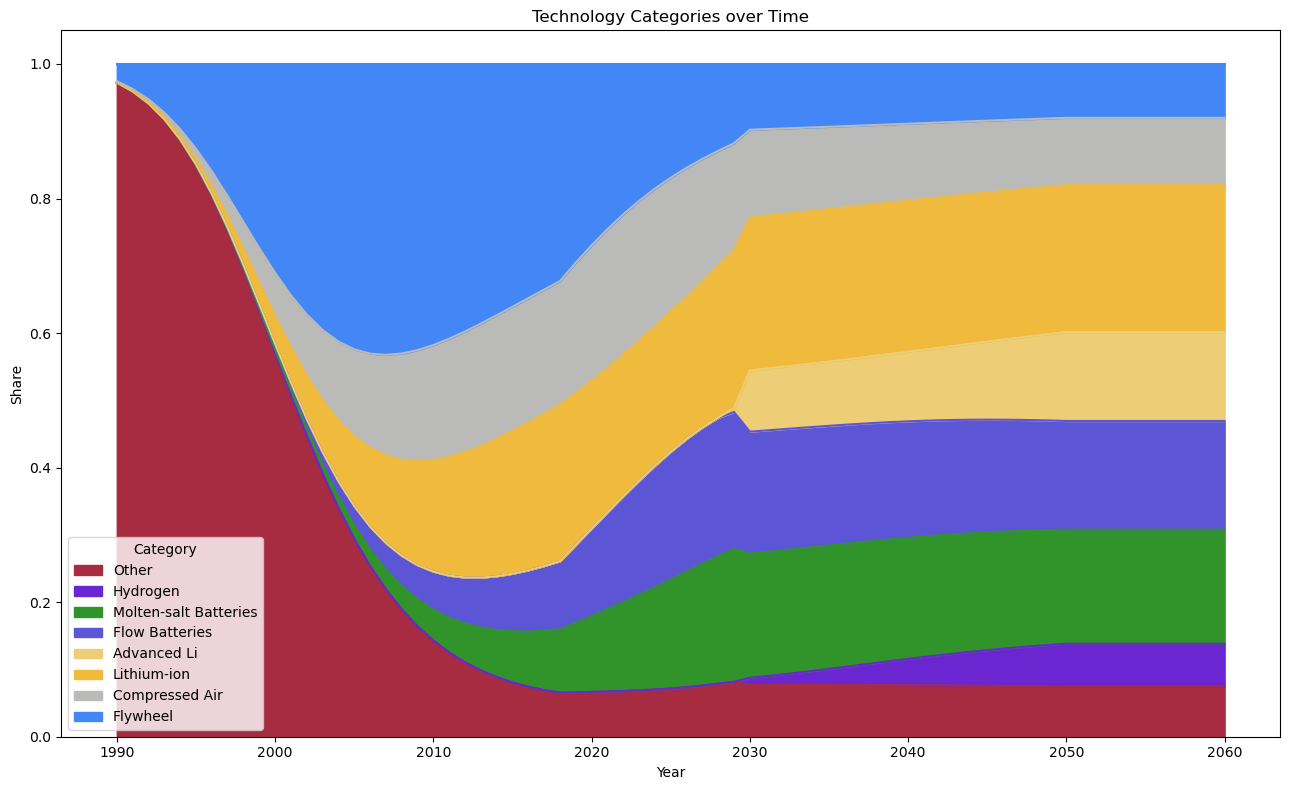

In [ ]:
import matplotlib.pyplot as plt

test_da = prep_data_oth_storage["shares"]

# Example dictionary mapping technologies to subcategories
tech_map_Sebastiaan = {
    'NiMH': 'Other',
    'LFP': 'Lithium-ion',
    'LMO': 'Lithium-ion',
    'LTO': 'Lithium-ion',
    'NMC': 'Lithium-ion',
    'NCA': 'Lithium-ion',
    'Lithium Sulfur': 'Advanced Li',
    'Lithium Ceramic': 'Advanced Li',
    'Lithium-air': 'Advanced Li',
    'Flywheel': 'Flywheel',
    'Compressed Air': 'Compressed Air',
    'Hydrogen FC': 'Hydrogen',
    'Zinc-Bromide': 'Flow Batteries',
    'Vanadium Redox': 'Flow Batteries',
    'Sodium-Sulfur': 'Molten-salt Batteries',
    'ZEBRA': 'Molten-salt Batteries',
    'Deep-cycle Lead-Acid': "Other",
}

# Color dictionary for categories
color_map = {
    'Lithium-ion':      '#F0BA3C',
    'Advanced Li':      '#EDCD76',
    'Flywheel':         '#4387F6',
    'Compressed Air':   '#BABAB8',
    'Hydrogen':         '#6A26D1',
    'Flow Batteries':   '#5C55D6',
    'Molten-salt Batteries': '#31942A',
    'Other':            '#A72C41',
}
category_order = ['Flywheel', 'Compressed Air', 'Lithium-ion', 'Advanced Li', 'Flow Batteries', 'Molten-salt Batteries', 'Hydrogen', 'Other']
category_order = ['Other', 'Hydrogen','Molten-salt Batteries', 'Flow Batteries', 'Advanced Li', 'Lithium-ion', 'Compressed Air','Flywheel' ]

# Get the types from your DataArray
types = test_da.Type.values  # da is your xarray.DataArray
# Map each type to its category
categories = [tech_map_Sebastiaan[t] for t in types]
# Assign as a new coordinate or DataArray
da_grouped = test_da.assign_coords(Category=('Type', categories))

# Sum over technologies within the same category
category_sum = da_grouped.groupby('Category').sum(dim='Type')
# Convert to pandas for plotting
df = category_sum.to_pandas()
df = df[category_order]

fig, ax = plt.subplots(figsize=(13, 8))
# Plot stacked bar with defined colors
df.loc[1990:2060,:].plot.area(ax=ax, stacked=True, color=[color_map[c] for c in df.columns])
plt.xlabel('Year')  # or 'Cohort'
plt.ylabel('Share')
plt.title('Technology Categories over Time')
plt.legend(title='Category')
plt.tight_layout()
# fig.savefig(path_test_plots / f"Market_shares.png", dpi=300, bbox_inches='tight')
plt.show()
